# Model Project

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
from Consumer import ConsumerClass
from Government import GovernmentClass

## 1. 

### 1.1

The consumer's problem is written in nested budget shares $(s_1, w)$: $s_1$ is
the share of income spent on food, $w$ is the share of the travel budget spent
on the bus. `utility()` gives nested CES utility from quantities; 
`value_of_choice()` gives it directly from the nested shares.

In [2]:
model = ConsumerClass()
print(model.value_of_choice(0.6, 0.5))  

3.3364917044408773


### 1.2

Two calibrations, differing only in $\sigma_B$: complements ($\sigma_B=0.40$)
and substitutes ($\sigma_B=3.00$).

In [3]:
model_complements = ConsumerClass()
model_substitutes = ConsumerClass(par={'sigma_B': 3.0})

### 2.1

In [4]:
opt_complements = model_complements.solve_grid(N=200)
opt_substitutes = model_substitutes.solve_grid(N=200)

grid search (N=200): s1 = 0.5377, s2 = 0.2021, s3 = 0.2602, u = 3.4016
grid search (N=200): s1 = 0.5377, s2 = 0.3206, s3 = 0.1417, u = 3.4851


The grid search (N=200) gives $s_1 \approx 0.538$ in both calibrations - the
consumer spends just over half of income on food regardless of $\sigma_B$.
The difference is in the travel nest: with complements ($\sigma_B=0.40$) the
budget is split more evenly between bus and train, since they are hard to
substitute for one another; with substitutes ($\sigma_B=3.00$) the consumer
buys far more bus than train, since they are easy to substitute and bus is
cheaper.

Plot utility over the nested shares in 3D and as a contour plot, with the grid-search solution marked in red for both calibrations.

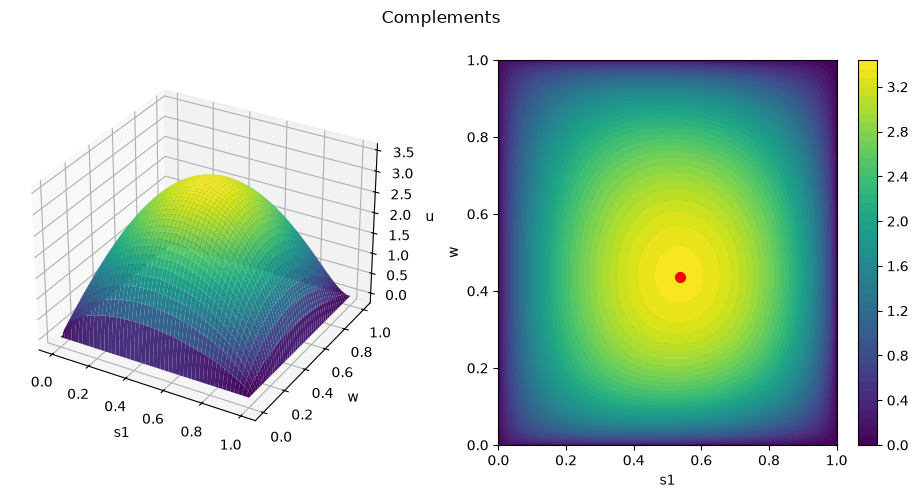

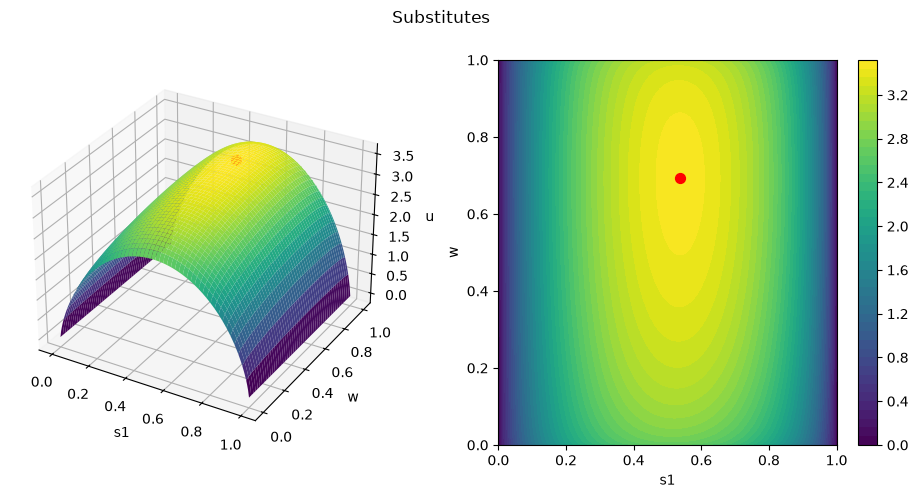

In [5]:
def plot_solution(opt,title):

    fig = plt.figure(figsize=(12,5))
    fig.suptitle(title)

    # a. 3D surface
    ax = fig.add_subplot(1,2,1,projection='3d')
    ax.plot_surface(opt.s1_grid,opt.w_grid,opt.u_grid,cmap='viridis')
    ax.scatter(opt.s1,opt.w,opt.u,color='red',s=50)
    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_zlabel('u')

    # b. contour plot
    ax = fig.add_subplot(1,2,2)
    cs = ax.contourf(opt.s1_grid,opt.w_grid,opt.u_grid,levels=50,cmap='viridis')
    ax.scatter(opt.s1,opt.w,color='red',s=50)
    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    fig.colorbar(cs,ax=ax)

    plt.show()

plot_solution(opt_complements,'Complements')
plot_solution(opt_substitutes,'Substitutes')

Comparing the two calibrations: the complements surface has a clearly rounded
peak, so the gradient is informative everywhere near the top. The substitutes
surface instead has a flat ridge running in the $w$-direction near the top -
many combinations of $w$ give almost the same utility once $s_1$ is near its
optimum. This makes the substitutes calibration harder for a gradient-based
optimizer, even though the true optimum is still unique.

Compare N = 50, 100, 500, 1000: How much the solutions moves, and how many evaluations of u it costs.

In [6]:
import time

for model,name in [(model_complements,'Complements'),(model_substitutes,'Substitutes')]:
    print(name)
    for N in [50,100,500,1000]:
        t0 = time.perf_counter()
        opt = model.solve_grid(N=N,do_print=False)
        t1 = time.perf_counter()
        print(f'  N = {N:5d}: s1 = {opt.s1:.4f}, w = {opt.w:.4f}, u = {opt.u:.6f}, ' +
              f'evaluations = {N**2:>8,d}, time = {t1-t0:.4f} s')
    print()

Complements
  N =    50: s1 = 0.5306, w = 0.4490, u = 3.400748, evaluations =    2,500, time = 0.0005 s
  N =   100: s1 = 0.5354, w = 0.4444, u = 3.401482, evaluations =   10,000, time = 0.0007 s
  N =   500: s1 = 0.5351, w = 0.4389, u = 3.401674, evaluations =  250,000, time = 0.0199 s
  N =  1000: s1 = 0.5355, w = 0.4394, u = 3.401680, evaluations = 1,000,000, time = 0.0863 s

Substitutes
  N =    50: s1 = 0.5306, w = 0.6939, u = 3.484594, evaluations =    2,500, time = 0.0012 s
  N =   100: s1 = 0.5354, w = 0.6970, u = 3.485005, evaluations =   10,000, time = 0.0008 s
  N =   500: s1 = 0.5391, w = 0.6914, u = 3.485097, evaluations =  250,000, time = 0.0170 s
  N =  1000: s1 = 0.5385, w = 0.6927, u = 3.485104, evaluations = 1,000,000, time = 0.0753 s



Utility improves smoothly and monotonically for both calibrations as $N$
grows, while the cost rises quadratically with $N$ (from 2,500 to 1,000,000
evaluations). Most of the improvement already happens by $N=100$–$500$;
going to $N=1000$ buys very little extra precision for a 4x increase in cost.

### 2.2

Solve with `solve()`, and compare the solution, the number of function
evaluations, and the running time with the grid search.

In [7]:
for model,name in [(model_complements,'Complements'),(model_substitutes,'Substitutes')]:
    print(name)
    t0 = time.perf_counter()
    opt_lbfgsb = model.solve(do_print=False)
    t1 = time.perf_counter()
    print(f'  L-BFGS-B: s1 = {opt_lbfgsb.s1:.4f}, w = {opt_lbfgsb.w:.4f}, u = {opt_lbfgsb.u:.6f}, ' +
          f'evaluations = {opt_lbfgsb.res.nfev}, time = {t1-t0:.4f} s')
    print()

Complements
  L-BFGS-B: s1 = 0.5356, w = 0.4395, u = 3.401680, evaluations = 18, time = 0.0025 s

Substitutes
  L-BFGS-B: s1 = 0.5382, w = 0.6923, u = 3.485105, evaluations = 27, time = 0.0013 s



L-BFGS-B reaches the same solution as the $N=1000$ grid search (matching to
4+ decimals in $u$) using only 18–27 function evaluations - tens of
thousands of times fewer than the grid, and in a fraction of the time.

Record the convergence path with the callback, and draw it on top of the contour plot. Then plot the distance from each iteration to the final point, on a log scale.

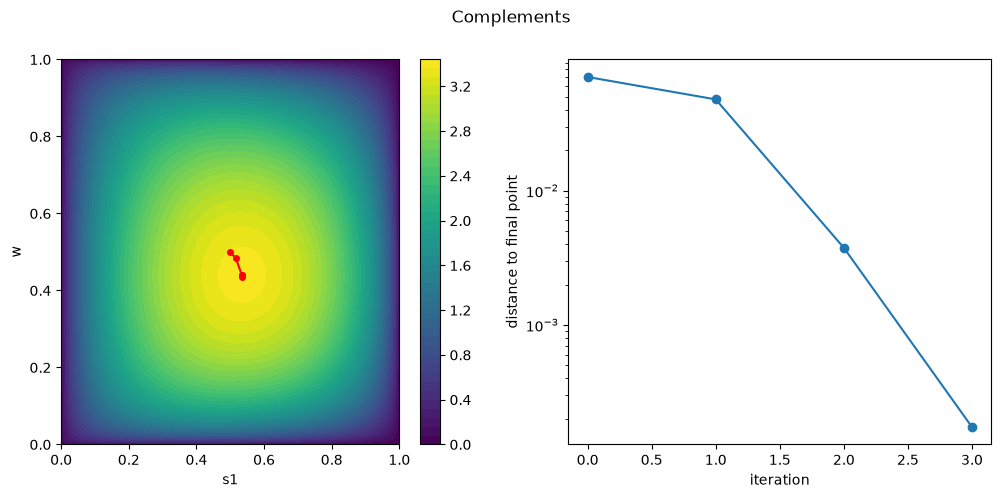

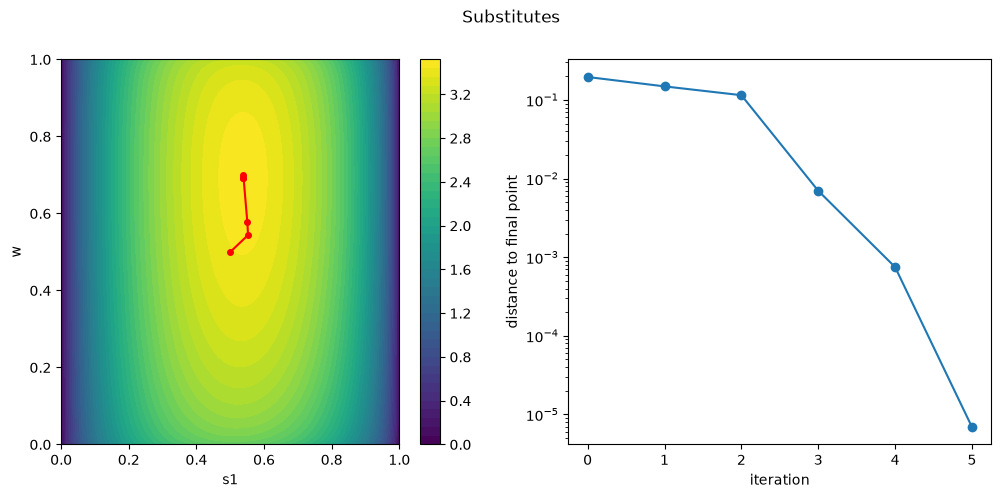

In [8]:
opt_lbfgsb_complements = model_complements.solve(do_print=False)
opt_lbfgsb_substitutes = model_substitutes.solve(do_print=False)

def plot_convergence(opt_grid,opt_lbfgsb,title):

    path = opt_lbfgsb.path

    fig,axes = plt.subplots(1,2,figsize=(12,5))
    fig.suptitle(title)

    # a. contour plot with the path
    ax = axes[0]
    cs = ax.contourf(opt_grid.s1_grid,opt_grid.w_grid,opt_grid.u_grid,levels=50,cmap='viridis')
    ax.plot(path[:,0],path[:,1],'-o',color='red',markersize=4)
    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    fig.colorbar(cs,ax=ax)

    # b. distance to the final point, on a log scale
    ax = axes[1]
    dist = np.linalg.norm(path - path[-1],axis=1)
    ax.plot(dist[:-1],'-o')
    ax.set_yscale('log')
    ax.set_xlabel('iteration')
    ax.set_ylabel('distance to final point')

    plt.show()

plot_convergence(opt_complements,opt_lbfgsb_complements,'Complements')
plot_convergence(opt_substitutes,opt_lbfgsb_substitutes,'Substitutes')

For both calibrations, the path moves almost directly toward the optimum.
The distance to the final point falls close to a straight line on the log
scale, meaning progress is fast in the first couple of iterations and slows
as the solver approaches the peak in the flatter directions.

Solve from at least six different starting points, including the middle (0.5, 0.5) and the four corners of the square. Do you always get the same answer? Does the number of iterations change? One corner fails in one calibration, while still reporting `success = True`.

In [9]:
starting_points = [
    ('middle',[0.5,0.5]),
    ('corner (0,0)',[0.0,0.0]),
    ('corner (0,1)',[0.0,1.0]),
    ('corner (1,0)',[1.0,0.0]),
    ('corner (1,1)',[1.0,1.0]),
    ('near (0,0)',[0.01,0.01]),
]

for model,name in [(model_complements,'Complements'),(model_substitutes,'Substitutes')]:
    print(name)
    for label,s0 in starting_points:
        opt = model.solve(s0=s0,do_print=False)
        print(f'  {label:15s}: s1 = {opt.s1:.4f}, w = {opt.w:.4f}, u = {opt.u:.6f}, ' +
              f'nit = {opt.res.nit}, success = {opt.res.success}')
    print()

Complements
  middle         : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 4, success = True
  corner (0,0)   : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 7, success = True
  corner (0,1)   : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 9, success = True
  corner (1,0)   : s1 = 1.0000, w = 0.0000, u = 0.000000, nit = 1, success = True
  corner (1,1)   : s1 = 1.0000, w = 1.0000, u = 0.000000, nit = 1, success = True
  near (0,0)     : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 6, success = True

Substitutes
  middle         : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 6, success = True
  corner (0,0)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 18, success = True
  corner (0,1)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 17, success = True
  corner (1,0)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 18, success = True
  corner (1,1)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 16, success = True
  near (0,0)     : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 8, su

L-BFGS-B always finds the same answer in the substitutes calibration,
regardless of starting point. In complements, however, the corners
$(1,0)$ and $(1,1)$ fail: the solver stops after `nit = 1` with $u = 0$,
while still reporting `success = True`. Both starting points have $s_1=1$,
which floors $x_2$ and $x_3$ to `par.s_min`. Because $\sigma_B<1$ here, the
lower nest is dominated by whichever quantity is smallest, so a small step
away from the floor barely changes utility - the estimated gradient is
numerically zero, and L-BFGS-B incorrectly reports convergence at the very
first point. This does not happen for substitutes, since $\sigma_B>1$ makes
the nest behave more like an average, so the gradient is picked up correctly
even at the boundary.

Vary `ftol`and `gtol`, and report the two shares, the utility reached, and the number of function evaluations for each setting in one table.

In [10]:
settings = [('ftol',1e-4),('ftol',1e-8),('ftol',1e-12),('ftol',1e-16),
            ('gtol',1e-2),('gtol',1e-5),('gtol',1e-8),('gtol',1e-12)]

rows = []
for name,model in [('Complements',model_complements),('Substitutes',model_substitutes)]:
    for setting,value in settings:
        opt = model.solve(do_print=False,options={setting:value})
        rows.append({'calibration':name,'setting':setting,'value':value,
                     's1':opt.s1,'w':opt.w,'u':opt.u,'nfev':opt.res.nfev})

df = pd.DataFrame(rows)
df

,calibration,setting,value,s1,w,u,nfev
0,Complements,ftol,1.000000e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol,1.000000e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol,1.000000e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol,1.000000e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol,1.000000e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol,1.000000e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol,1.000000e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol,1.000000e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol,1.000000e-08,0.538225,0.692308,3.485105,27


From `ftol=1e-8` (or `gtol=1e-5`) onward, $s_1$, $w$ and $u$ no longer change
for either calibration - only the evaluation count creeps up slightly. We
would use `ftol=1e-8` and `gtol=1e-5`: tighter tolerances cost extra
evaluations without changing the answer, because the improvement they chase
is smaller than the numerical precision the model can actually distinguish
(cf. floating-point precision) - a tighter tolerance is not always better.

### 1.3

Two cheap checks, using the results from section 2: (1) is the answer possible - shares strictly between 0 and 1, summing to one, quantities positive; (2) do the two solution methods (grid search and L-BFGS-B) agree?

In [11]:
for name,opt_grid,opt_lbfgsb,model in [
    ('Complements',opt_complements,opt_lbfgsb_complements,model_complements),
    ('Substitutes',opt_substitutes,opt_lbfgsb_substitutes,model_substitutes)]:

    print(name)

    # a. is the answer possible?
    x1,x2,x3 = model.quantities(opt_lbfgsb.s1,opt_lbfgsb.w)
    shares_ok = all(0 < s < 1 for s in (opt_lbfgsb.s1,opt_lbfgsb.s2,opt_lbfgsb.s3))
    sum_ok = np.isclose(opt_lbfgsb.s1+opt_lbfgsb.s2+opt_lbfgsb.s3,1.0)
    quantities_ok = all(x > 0 for x in (x1,x2,x3))
    print(f'  possible: shares in (0,1) = {shares_ok}, sum to 1 = {sum_ok}, quantities > 0 = {quantities_ok}')

    # b. do grid search and L-BFGS-B agree?
    agree = np.isclose(opt_grid.u,opt_lbfgsb.u,atol=1e-3)
    print(f'  agreement: grid u = {opt_grid.u:.6f}, L-BFGS-B u = {opt_lbfgsb.u:.6f}, agree = {agree}')
    print()

Complements
  possible: shares in (0,1) = True, sum to 1 = True, quantities > 0 = True
  agreement: grid u = 3.401601, L-BFGS-B u = 3.401680, agree = True

Substitutes
  possible: shares in (0,1) = True, sum to 1 = True, quantities > 0 = True
  agreement: grid u = 3.485100, L-BFGS-B u = 3.485105, agree = True



Both cheap checks pass for both calibrations: all three shares lie strictly
between 0 and 1 and sum to one, all three quantities are positive, and the
two independent solution methods (grid search and L-BFGS-B) agree on the
utility reached. This gives confidence that sections 1–2 are solved
correctly.

## 3.

Solve the model for $p_3$ from 1.5 to 5.0, holding $p_1$, $p_2$ and $I$ fixed, and plot the three budget shares and the three quantities for both calibrations.

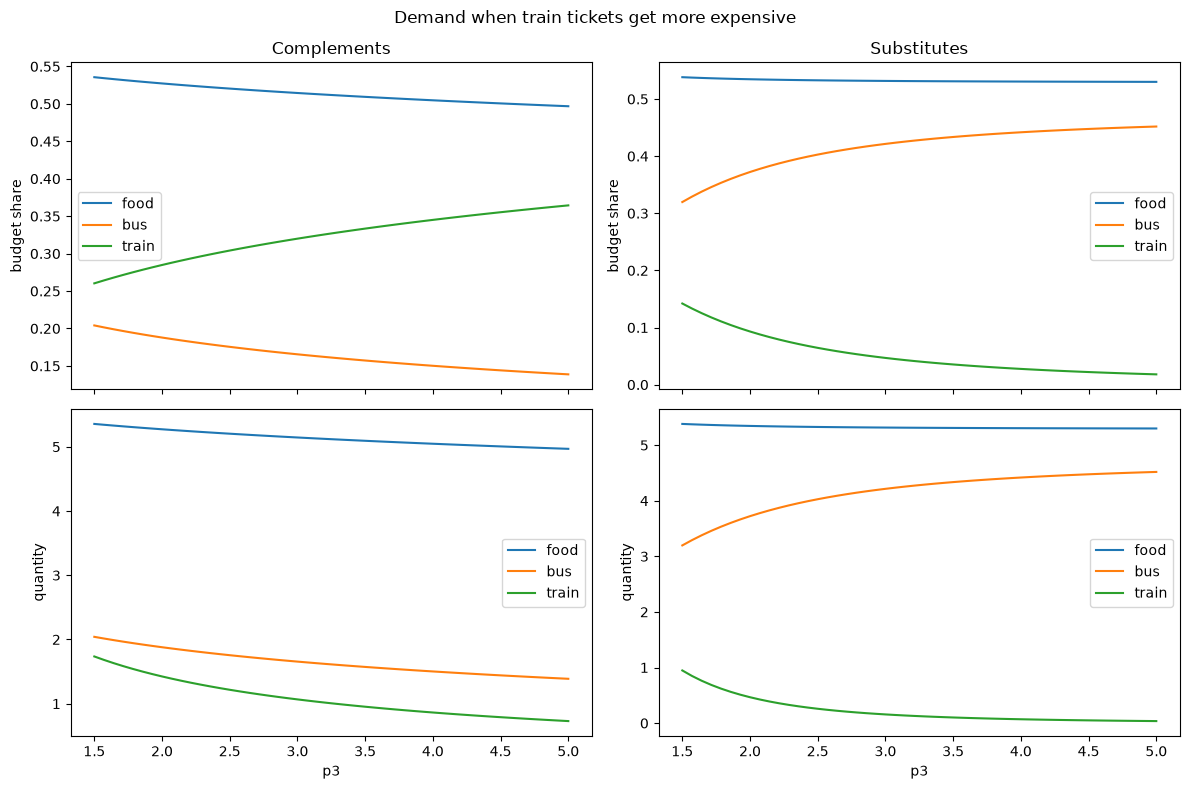

In [12]:
p3_vec = np.linspace(1.5,5.0,50)

def solve_for_p3(sigma_B):

    shares = np.empty((p3_vec.size,3))
    quantities = np.empty((p3_vec.size,3))

    # a. a fresh consumer for each price, so the models above are left untouched
    for i,p3 in enumerate(p3_vec):
        model = ConsumerClass(par={'sigma_B':sigma_B,'p3':p3})
        opt = model.solve(do_print=False)

        # b. store the solution
        shares[i,:] = [opt.s1,opt.s2,opt.s3]
        quantities[i,:] = model.quantities(opt.s1,opt.w)

    return shares,quantities

shares_complements,quantities_complements = solve_for_p3(0.40)
shares_substitutes,quantities_substitutes = solve_for_p3(3.00)

def plot_demand():

    labels = ['food','bus','train']
    colors = ['C0','C1','C2']

    fig,axes = plt.subplots(2,2,figsize=(12,8),sharex=True)
    fig.suptitle('Demand when train tickets get more expensive')

    for col,(title,shares,quantities) in enumerate([
        ('Complements',shares_complements,quantities_complements),
        ('Substitutes',shares_substitutes,quantities_substitutes)]):

        # a. budget shares
        ax = axes[0,col]
        for j in range(3):
            ax.plot(p3_vec,shares[:,j],color=colors[j],label=labels[j])
        ax.set_title(title)
        ax.set_ylabel('budget share')
        ax.legend()

        # b. quantities
        ax = axes[1,col]
        for j in range(3):
            ax.plot(p3_vec,quantities[:,j],color=colors[j],label=labels[j])
        ax.set_xlabel('p3')
        ax.set_ylabel('quantity')
        ax.legend()

    fig.tight_layout()
    plt.show()

plot_demand()

In which calibration does a higher $p_3$ raise the budget share of the train, and in which does it lower it? What happens to the number of bus trips? And how much does the price of a train ticket change the demand for food, compared with the effect on bus trips?

The budget share of the train: A higher $p_3$ raises the budget share of
the train under complements, from 0.260 to 0.364, and lowers it under
substitutes, from 0.142 to 0.018. The sign is governed by $\sigma_B$: train
demand is price-inelastic when $\sigma_B<1$, so spending on it rises even
though the quantity falls, and price-elastic when $\sigma_B>1$, so spending
collapses.

Bus trips: Bus trips move in opposite directions in the two
calibrations. Under complements they fall by 32%, from 2.04 to 1.39, since
bus and train are consumed together and a more expensive train makes the
whole travel composite expensive. Under substitutes they rise by 41%, from
3.20 to 4.52, as the consumer switches out of the train and into the cheaper
bus, train trips very nearly disappear, falling by 96%.

The demand for food: The effect on food is small in both calibrations,
and much smaller than the effect on bus trips: food falls by 7.2% under
complements but only 1.5% under substitutes. The nest structure is the
reason. Under substitutes the price rise is absorbed within the travel nest
by switching to the bus, so almost nothing spills over into the upper nest,
while under complements no such switch is available and the loss has to be
shared with food.

## 4.

Implement `tax_revenue()`. Then consider five product taxes: on food only, on the bus only, on the train only, the same rate on bus and train, and the same rate on all three goods. For each of them, plot the revenue as a function of the tax rate for rates from 0 to 3, one panel per calibration.

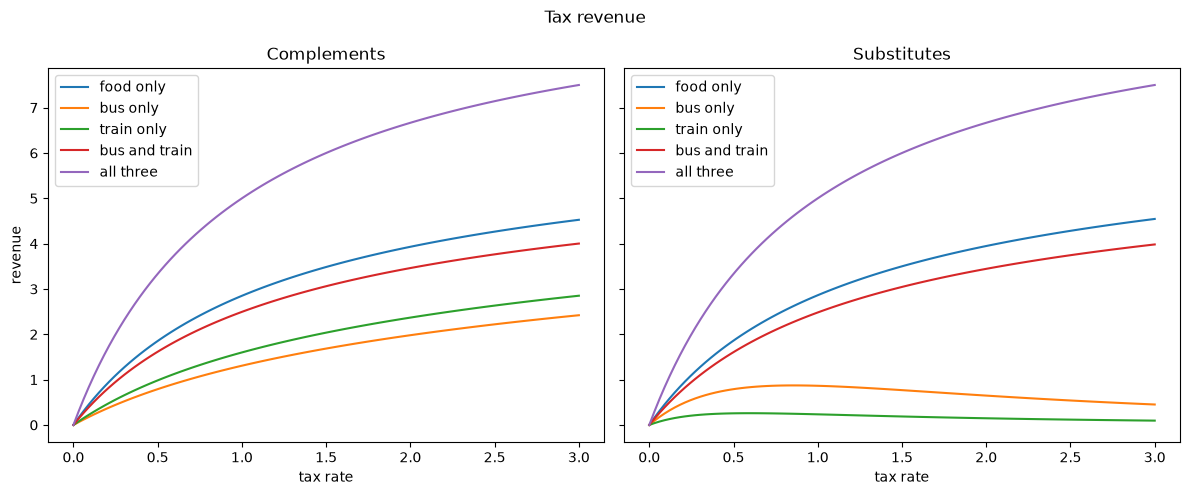

In [13]:
gov_complements = GovernmentClass()
gov_substitutes = GovernmentClass(par={'sigma_B':3.0})

instruments = [('food only',(1,)),('bus only',(2,)),('train only',(3,)),
               ('bus and train',(2,3)),('all three',(1,2,3))]

tau_vec = np.linspace(0,3,100)

def revenue_curves(gov):

    R = {}
    u = {}

    # a. the five product taxes
    for label,goods in instruments:
        out = np.array([gov.revenue_and_utility(tau,goods) for tau in tau_vec])
        R[label],u[label] = out[:,0],out[:,1]

    # b. the lump-sum tax
    out = np.array([gov.revenue_and_utility_lump_sum(T) for T in tau_vec])
    R['lump-sum'],u['lump-sum'] = out[:,0],out[:,1]

    return R,u

R_complements,u_complements = revenue_curves(gov_complements)
R_substitutes,u_substitutes = revenue_curves(gov_substitutes)

def plot_revenue():

    fig,axes = plt.subplots(1,2,figsize=(12,5),sharey=True)
    fig.suptitle('Tax revenue')

    for ax,(title,R) in zip(axes,[('Complements',R_complements),('Substitutes',R_substitutes)]):
        for label,goods in instruments:
            ax.plot(tau_vec,R[label],label=label)
        ax.set_title(title)
        ax.set_xlabel('tax rate')
        ax.legend()

    axes[0].set_ylabel('revenue')

    fig.tight_layout()
    plt.show()

plot_revenue()

Which of the curves have a top, and which just keep rising? Find the revenue-maximizing rate and the largest possible revenue where there is a top. In particular: what is the most that a tax on train tickets alone can ever raise in the substitutes calibration?

In [14]:
rows = []
for name,gov in [('Complements',gov_complements),('Substitutes',gov_substitutes)]:
    for label,goods in instruments:
        tau,R = gov.max_revenue(goods=goods,tau_max=3.0,N=301)
        rows.append({'calibration':name,'instrument':label,'tau*':tau,
                     'R_max':R,'top':tau < 2.99})

df_max = pd.DataFrame(rows)
df_max

,calibration,instrument,tau*,R_max,top
0,Complements,food only,3.00,4.526108,False
1,Complements,bus only,3.00,2.420563,False
2,Complements,train only,3.00,2.850957,False
3,Complements,bus and train,3.00,4.001854,False
4,Complements,all three,3.00,7.500000,False
5,Substitutes,food only,3.00,4.544876,False
6,Substitutes,bus only,0.86,0.872136,True
7,Substitutes,train only,0.59,0.259037,True
8,Substitutes,bus and train,3.00,3.982312,False
9,Substitutes,all three,3.00,7.500000,False


Which curves have a top: Only two of the ten curves turn: the bus-only tax
and the train-only tax, and only in the substitutes calibration. The bus tax
peaks at a rate of 0.86 raising 0.872, and the train tax peaks at 0.59 raising
0.259. Everything else keeps rising over the whole range. The pattern follows
$\sigma$: a Laffer top requires the taxed good to be price-elastic, so that
the base shrinks faster than the rate grows. That happens only inside the
travel nest when $\sigma_B>1$. Food is inelastic ($\sigma_A<1$), the bus-and-
train tax hits the whole travel composite which is inelastic against food, and
the tax on all three goods is a proportional cut in real income, so its
revenue rises towards $I$ without ever turning.

The train tax under substitutes: The most a tax on train tickets alone can
ever raise is 0.259, at a rate of 0.59 - only 2.6% of income. Beyond that the
consumer simply switches to the bus and the base disappears. This is the tightest
ceiling of any instrument here, and it matters for the revenue requirement below.

Plot the consumer's utility against the revenue raised, for all five product taxes and for the lump-sum tax, one panel per calibration. Which instrument is the cheapest way to raise a given revenue, and does the ranking depend on the calibration?

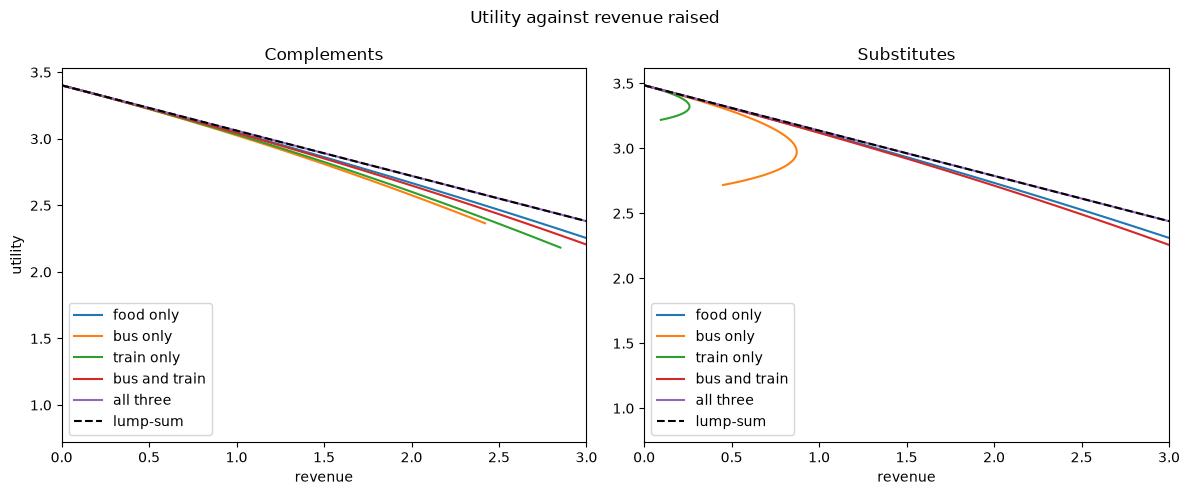

In [16]:
def plot_utility_against_revenue():

    fig,axes = plt.subplots(1,2,figsize=(12,5))
    fig.suptitle('Utility against revenue raised')

    for ax,(title,R,u) in zip(axes,[('Complements',R_complements,u_complements),
                                    ('Substitutes',R_substitutes,u_substitutes)]):
        for label,goods in instruments:
            ax.plot(R[label],u[label],label=label)
        ax.plot(R['lump-sum'],u['lump-sum'],'k--',label='lump-sum')
        ax.set_title(title)
        ax.set_xlabel('revenue')
        ax.set_xlim(0,3)
        ax.legend()

    axes[0].set_ylabel('utility')

    fig.tight_layout()
    plt.show()

plot_utility_against_revenue()

The cheapest instrument: The lump-sum tax is the cheapest way to raise any
given revenue in both calibrations, its curve is the upper envelope of all the
others. The tax on all three goods lies exactly on top of it, which is not a
coincidence: taxing every good at the same rate leaves all relative prices
unchanged and is therefore just a proportional cut in real income, exactly what
a lump-sum tax does. Every tax that hits only some goods distorts the choice
between them and does strictly worse.

Does the ranking depend on the calibration? The top of the ranking does not
- lump-sum and the uniform tax are best in both. The bottom does. Under
complements the bus tax is the worst and the train tax second worst, while under
substitutes they swap: the train tax becomes by far the most expensive, and its
curve bends backwards, so past a revenue of 0.259 it cannot deliver at all.

Let the government need $R=0.2$, i.e. 2 percent of income. Use a root-finder to find the tax rate that raises exactly that for each instrument, and report the rate and the resulting utility in one table per calibration. Rank the instruments, and comment in particular on the tax on train tickets.

In [17]:
R_target = 0.2

rows = []
for name,gov in [('Complements',gov_complements),('Substitutes',gov_substitutes)]:

    # a. the five product taxes
    for label,goods in instruments:
        tau = gov.find_tax_rate(R_target,goods=goods,bracket=(1e-10,1.0))
        if np.isnan(tau):
            rows.append({'calibration':name,'instrument':label,'rate':np.nan,'u':np.nan})
        else:
            R,u = gov.revenue_and_utility(tau,goods)
            rows.append({'calibration':name,'instrument':label,'rate':tau,'u':u})

    # b. the lump-sum tax, where the rate is the revenue itself
    R,u = gov.revenue_and_utility_lump_sum(R_target)
    rows.append({'calibration':name,'instrument':'lump-sum','rate':R_target,'u':u})

df_target = pd.DataFrame(rows)
for name in ['Complements','Substitutes']:
    print(name)
    print(df_target[df_target['calibration']==name].sort_values('u',ascending=False).to_string(index=False))
    print()

Complements
calibration    instrument     rate        u
Complements      lump-sum 0.200000 3.333646
Complements     all three 0.020408 3.333646
Complements     food only 0.038647 3.333169
Complements bus and train 0.044787 3.333010
Complements    train only 0.081011 3.332548
Complements      bus only 0.104215 3.332260

Substitutes
calibration    instrument     rate        u
Substitutes     all three 0.020408 3.415402
Substitutes      lump-sum 0.200000 3.415402
Substitutes     food only 0.038454 3.414919
Substitutes bus and train 0.045049 3.414744
Substitutes      bus only 0.069532 3.412375
Substitutes    train only 0.236217 3.395521



The ranking:  In both calibrations the order is the same at the top:
lump-sum and the uniform tax on all three goods are tied at the highest utility
(3.3336 under complements, 3.4154 under substitutes), followed by the food tax,
then the bus-and-train tax. The two narrow taxes come last. The differences are
small in absolute terms because the revenue requirement is small, all six
instruments cost the consumer roughly 0.068 in utility, against the 0.2 of
income actually handed over, but the ordering is clean and identical to the
envelope in the figure above.

The tax on train tickets: This is where the two calibrations part company.
Under complements the train tax needs a rate of 0.081 and leaves utility at
3.3325, unremarkable, and second-worst. Under substitutes it needs a rate of
0.236, nearly three times as high, and leaves utility at 3.3955, clearly the
worst of the six. The reason is the ceiling found above: the most this
instrument can ever raise is 0.259, so a requirement of 0.2 already takes it to
77% of everything it has. The base has to be squeezed hard, and the consumer
pays for it by distorting his travel choice away from the train he would
otherwise have taken.